# HR Attrition Analysis — Data Cleaning & Feature Engineering

**Dataset:** IBM HR Analytics Employee Attrition & Performance (Kaggle)
**Goal:** Clean the data, engineer features, and export a Power BI–ready dataset for an HR overview dashboard.

This notebook covers:
1. Load & inspect the raw data
2. Clean column names and data types
3. Handle redundant / constant columns
4. Engineer a custom **Attrition Risk Score** (differentiator feature)
5. Bucket continuous variables for easier filtering in Power BI
6. Export cleaned tables for Power BI import


## 1. Load & Inspect

In [15]:
import pandas as pd
import numpy as np

# Update this path to wherever you saved the downloaded CSV
INPUT_FILE = "WA_Fn-UseC_-HR-Employee-Attrition.csv"

df = pd.read_csv(INPUT_FILE)

print("Shape:", df.shape)
df.head()


Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [16]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [17]:
# Check for missing values
df.isnull().sum().sort_values(ascending=False).head(10)


Age                 0
Attrition           0
BusinessTravel      0
DailyRate           0
Department          0
DistanceFromHome    0
Education           0
EducationField      0
EmployeeCount       0
EmployeeNumber      0
dtype: int64

In [18]:
# Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 0


## 2. Clean Column Names & Drop Useless Columns

The IBM dataset has a few columns that are constant across all rows (no analytical value) —
e.g. `EmployeeCount`, `Over18`, `StandardHours`. We drop these.


In [19]:
# Standardize column names (snake_case for easier referencing)
df.columns = [c.strip() for c in df.columns]

# Identify constant columns (same value in every row -> no analytical value)
constant_cols = [c for c in df.columns if df[c].nunique() == 1]
print("Constant columns to drop:", constant_cols)

df = df.drop(columns=constant_cols)
print("New shape:", df.shape)


Constant columns to drop: ['EmployeeCount', 'Over18', 'StandardHours']
New shape: (1470, 32)


In [20]:
# EmployeeNumber is just an ID - keep it but don't treat as a feature
# Confirm attrition target column
df['Attrition'].value_counts(normalize=True)


Attrition
No     0.838776
Yes    0.161224
Name: proportion, dtype: float64

## 3. Data Type Fixes

Convert categorical-looking numeric codes (like `Education`, `JobSatisfaction`) into labeled
categories where it helps readability in Power BI tooltips and visuals.


In [21]:
education_map = {1: 'Below College', 2: 'College', 3: 'Bachelor', 4: 'Master', 5: 'Doctor'}
satisfaction_map = {1: '1-Low', 2: '2-Medium', 3: '3-High', 4: '4-Very High'}
worklife_map = {1: '1-Bad', 2: '2-Good', 3: '3-Better', 4: '4-Best'}
involvement_map = {1: 'Low', 2: 'Medium', 3: 'High', 4: 'Very High'}
perf_map = {1: 'Low', 2: 'Good', 3: 'Excellent', 4: 'Outstanding'}

df['EducationLabel'] = df['Education'].map(education_map)
df['JobSatisfactionLabel'] = df['JobSatisfaction'].map(satisfaction_map)
df['EnvironmentSatisfactionLabel'] = df['EnvironmentSatisfaction'].map(satisfaction_map)
df['RelationshipSatisfactionLabel'] = df['RelationshipSatisfaction'].map(satisfaction_map)
df['WorkLifeBalanceLabel'] = df['WorkLifeBalance'].map(worklife_map)
df['JobInvolvementLabel'] = df['JobInvolvement'].map(involvement_map)
df['PerformanceRatingLabel'] = df['PerformanceRating'].map(perf_map)

df[['Education','EducationLabel','JobSatisfaction','JobSatisfactionLabel']].head()


,Education,EducationLabel,JobSatisfaction,JobSatisfactionLabel
0,2,College,4,4-Very High
1,1,Below College,2,2-Medium
2,2,College,3,3-High
3,4,Master,3,3-High
4,1,Below College,2,2-Medium


## 4. Engineer a Custom Attrition Risk Score (Differentiator)

Instead of just showing raw attrition stats, we combine several known risk factors into a single
weighted score. This is the kind of feature that makes a dashboard look like real analyst work,
not a tutorial copy.

**Logic:** higher risk score = higher likelihood of leaving, based on patterns common in attrition
research: overtime, low satisfaction, low work-life balance, long time since promotion, low income
relative to role, and low job involvement.

Weights here are a reasonable starting point — feel free to tune them after looking at correlations
with actual `Attrition` in step 4b below.


In [22]:
# Normalize each risk factor to a 0-1 scale, then combine with weights

risk_df = pd.DataFrame(index=df.index)

# 1. Overtime (binary risk factor)
risk_df['overtime_risk'] = (df['OverTime'] == 'Yes').astype(int)

# 2. Low job satisfaction (inverse, normalized)
risk_df['job_satisfaction_risk'] = (5 - df['JobSatisfaction']) / 4

# 3. Low work-life balance (inverse, normalized)
risk_df['worklife_risk'] = (5 - df['WorkLifeBalance']) / 4

# 4. Years since last promotion (normalized, capped)
risk_df['promotion_risk'] = (df['YearsSinceLastPromotion'].clip(upper=10)) / 10

# 5. Low job involvement (inverse, normalized)
risk_df['involvement_risk'] = (5 - df['JobInvolvement']) / 4

# 6. Income relative to job level peers (low percentile within job level = higher risk)
df['income_percentile_in_level'] = df.groupby('JobLevel')['MonthlyIncome'].rank(pct=True)
risk_df['income_risk'] = 1 - df['income_percentile_in_level']

# Weighted combination (weights sum to 1, tune these based on correlation check below)
weights = {
    'overtime_risk': 0.25,
    'job_satisfaction_risk': 0.20,
    'worklife_risk': 0.15,
    'promotion_risk': 0.15,
    'involvement_risk': 0.15,
    'income_risk': 0.10,
}

df['AttritionRiskScore'] = sum(risk_df[col] * w for col, w in weights.items())
df['AttritionRiskScore'] = (df['AttritionRiskScore'] * 100).round(1)  # scale to 0-100

df[['EmployeeNumber','Attrition','AttritionRiskScore']].sort_values('AttritionRiskScore', ascending=False).head(10)


,EmployeeNumber,Attrition,AttritionRiskScore
838,1167,Yes,86.2
93,124,No,83.9
882,1237,No,82.3
914,1278,No,81.6
889,1244,No,80.7
451,605,No,80.5
62,80,No,80.5
966,1360,Yes,79.8
336,454,Yes,79.8
263,363,No,79.7


### 4b. Validate the risk score against actual attrition

If the score is meaningful, employees who actually left should have a higher average score than those who stayed.

In [23]:
df.groupby('Attrition')['AttritionRiskScore'].agg(['mean', 'median', 'count'])


,mean,median,count
Attrition,,,
No,41.707948,39.3,1233
Yes,52.364557,53.6,237


In [24]:
# Bucket the risk score into tiers for easy filtering/visuals in Power BI
df['RiskTier'] = pd.cut(
    df['AttritionRiskScore'],
    bins=[-1, 30, 50, 70, 101],
    labels=['Low', 'Medium', 'High', 'Critical']
)

df['RiskTier'].value_counts()


RiskTier
Medium      775
High        385
Low         247
Critical     63
Name: count, dtype: int64

## 5. Bucket Continuous Variables

Power BI filters/slicers work better with age bands and tenure bands than raw continuous values.


In [25]:
df['AgeBand'] = pd.cut(
    df['Age'], bins=[17,25,35,45,55,65],
    labels=['18-25','26-35','36-45','46-55','56-65']
)

df['TenureBand'] = pd.cut(
    df['YearsAtCompany'], bins=[-1,1,3,5,10,40],
    labels=['1-<1 yr','2-1-3 yrs','3-3-5 yrs','4-5-10 yrs','5-10+ yrs']
)

df[['Age','AgeBand','YearsAtCompany','TenureBand']].head()


,Age,AgeBand,YearsAtCompany,TenureBand
0,41,36-45,6,4-5-10 yrs
1,49,46-55,10,4-5-10 yrs
2,37,36-45,0,1-<1 yr
3,33,26-35,8,4-5-10 yrs
4,27,26-35,2,2-1-3 yrs


## 6. Quick Sanity-Check Visuals (optional, for your own EDA)

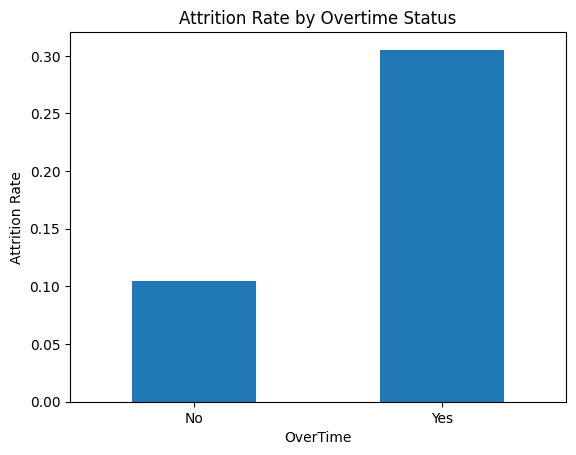

In [26]:
import matplotlib.pyplot as plt

attrition_by_overtime = df.groupby('OverTime')['Attrition'].apply(lambda x: (x=='Yes').mean())
attrition_by_overtime.plot(kind='bar', title='Attrition Rate by Overtime Status')
plt.ylabel('Attrition Rate')
plt.xticks(rotation=0)
plt.show()


## 7. Export Cleaned Data for Power BI

Export the full cleaned table. This single flat table is enough to import directly into Power BI —
no need to split into multiple tables for this dataset since there's no repeating multi-value field
like the skills column in the other dataset we considered.


In [27]:
OUTPUT_FILE = "hr_attrition_cleaned.csv"
df.to_csv(OUTPUT_FILE, index=False)
print(f"Exported -> {OUTPUT_FILE}")
print("Final shape:", df.shape)
print("Columns:", df.columns.tolist())


Exported -> hr_attrition_cleaned.csv
Final shape: (1470, 44)
Columns: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'EducationLabel', 'JobSatisfactionLabel', 'EnvironmentSatisfactionLabel', 'RelationshipSatisfactionLabel', 'WorkLifeBalanceLabel', 'JobInvolvementLabel', 'PerformanceRatingLabel', 'income_percentile_in_level', 'AttritionRiskScore', 'RiskTier', 'AgeBand', 'TenureBand']


## Next Step

Import `hr_attrition_cleaned.csv` into Power BI Desktop. In Power BI:
- Use `RiskTier`, `AgeBand`, `TenureBand` as slicers
- Use `AttritionRiskScore` for a top-risk-employees table/visual
- Use the `*Label` columns (e.g. `JobSatisfactionLabel`) instead of raw numbers in tooltips and axis labels for readability

This is where Step 3 (Power BI data model) picks up.
